In [2]:
import numpy as np
import matplotlib.pyplot as plt

import importlib

#from pyradet.signal import pulse as ps
#importlib.reload( ps )

In [3]:
def generate_pulse( *, length=2000, amplitude=500, tau1=10.0, tau2=100, noise_std=3, xoffset=250, yoffset=1000):

    if offset >= length:
        raise ValueError("Offset must be less than total length.")

    x = np.arange(length)
    xdata = np.heaviside( np.arange(length) - xoffset, 1 )

    # Double exponential: rising and falling edge
    pulse = amplitude * (1 - np.exp( -(x-offset) / tau1)) * np.exp( - (x-offset) / tau2) * xdata
    #if tau1 < 1:
    #    pulse = 0 * pulse
    #    pulse[1] = amplitude
    
    # Flat noisy baseline
    baseline = np.random.normal(yoffset, noise_std, size=length)

    return np.asarray( [round(i) for i in pulse + baseline] ), np.max(pulse),

In [8]:
def moving_average(waveform, N):
    """
    Smooth the waveform using a centered moving average of window size N.
    The output has the same length as the input, using edge-padding at boundaries.
    
    Parameters:
        waveform (np.ndarray): Input 1D waveform array
        N (int): Window size (must be odd)

    Returns:
        np.ndarray: Smoothed waveform of same length
    """
    if N % 2 == 0:
        N = N+1
    half_window = N // 2
    padded = np.pad(waveform, (half_window, half_window), mode='edge')
    kernel = np.ones(N) / N
    smoothed = np.convolve(padded, kernel, mode='valid')
    return smoothed

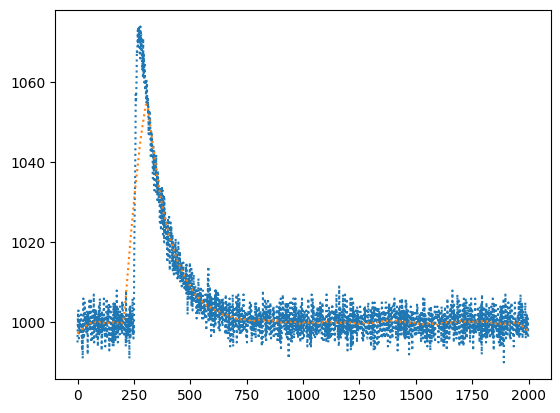

In [12]:
offset = 250
amp = 100
length=2000
y,amp = generate_pulse( xoffset = offset, amplitude=amp, length=length)
x = np.arange( length )
plt.plot(x, y, ls=':')
plt.plot(x, moving_average(y,100), ls=':')

#mean, dev, mask = ps.GetBaseline( y[:offset+10], return_array=True)
#print(mean)
#plt.plot(x[:offset+10][mask], y[:offset+10][mask], marker='.')
#plt.xlim([0,offset+10])

In [98]:
import itertools
from tqdm import tqdm  # for progress bar

# Grid of parameters to test
top_values = [i for i in range(5,16,1)]
min_count_values = [i for i in range(5, 15, 1)]
min_neighbour_values = [2,3,4,5]
vicinity_values = [2,3,4]

# Store results
results = []

# True pulse parameters
true_baseline = 500
n_trials = 50
error_penalty = 10

# pulse parameter
xoffset = 250
noise_std = 2
length=2000

# Sweep all combinations
param_grid = list(itertools.product(top_values, min_count_values, min_neighbour_values, vicinity_values))

for top, min_count, min_neighbour, vicinity in tqdm(param_grid):
    
    errors = []
    
    for _ in range(n_trials):
        
        pulse, amp = generate_pulse( length=length, xoffset=xoffset, yoffset=true_baseline, noise_std=noise_std)
        est_mean, dev = ps.GetBaseline( pulse[:xoffset+10], top=top, count=min_count, neighbour=min_neighbour, vicinity=vicinity)
        
        if np.isnan(est_mean):
            error = error_penalty
        else:
            error = abs(est_mean - true_baseline)
        
        errors.append(error)
        
    mean_error = np.mean(errors)
    std_error = np.std(errors)
    results.append(((top, min_count, min_neighbour, vicinity), mean_error, std_error))

# Sort by mean error
results.sort(key=lambda x: x[1])

# Display best results
print("\nTop 5 parameter sets with lowest mean error:")
for (top, min_count, min_neighbour, vicinity), mean_error, std_error in results[:5]:
    print(f"top={top:2}, min_count={min_count}, min_neigh={min_neighbour}, vicinity={vicinity} -> "
          f"mean error = {mean_error:.4f}, std = {std_error:.4f}")


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1320/1320 [01:49<00:00, 12.10it/s]


Top 5 parameter sets with lowest mean error:
top= 7, min_count=6, min_neigh=5, vicinity=4 -> mean error = 0.0945, std = 0.0904
top=13, min_count=13, min_neigh=4, vicinity=4 -> mean error = 0.1055, std = 0.0840
top=10, min_count=10, min_neigh=3, vicinity=4 -> mean error = 0.1071, std = 0.0831
top=14, min_count=13, min_neigh=4, vicinity=4 -> mean error = 0.1073, std = 0.0986
top=13, min_count=7, min_neigh=2, vicinity=4 -> mean error = 0.1082, std = 0.0765


When noise std = 2
Top 5 parameter sets with lowest mean error:
- top=10, min_count=6, min_neigh=2, vicinity=4 -> mean error = 0.0968, std = 0.0804
- top=11, min_count=7, min_neigh=2, vicinity=4 -> mean error = 0.1029, std = 0.0800
- top=14, min_count=11, min_neigh=4, vicinity=4 -> mean error = 0.1065, std = 0.0871
- top=13, min_count=13, min_neigh=2, vicinity=4 -> mean error = 0.1083, std = 0.0920
- top=15, min_count=11, min_neigh=3, vicinity=4 -> mean error = 0.1103, std = 0.0893

When noise std = 3
Top 5 parameter sets with lowest mean error:
top=14, min_count=13, min_neigh=4, vicinity=4 -> mean error = 0.3346, std = 0.2640
top=11, min_count=13, min_neigh=3, vicinity=4 -> mean error = 0.3359, std = 0.2560
top=15, min_count=6, min_neigh=2, vicinity=4 -> mean error = 0.3392, std = 0.2785
top=14, min_count=9, min_neigh=5, vicinity=4 -> mean error = 0.3475, std = 0.3001
top=15, min_count=7, min_neigh=3, vicinity=4 -> mean error = 0.3520, std = 0.2760

In [86]:
#print(results)
for (top, min_count, min_neighbour, vicinity), mean_error, std_error in results[:5]:
    print(f"top={top:2}, min_count={min_count}, min_neigh={min_neighbour}, vicinity={vicinity} -> "
          f"mean error = {mean_error}, std = {std_error}")

top= 9, min_count=11, min_neigh=4, vicinity=3 -> mean error = 0.0, std = 0.0
top=11, min_count=17, min_neigh=2, vicinity=3 -> mean error = 0.004166666666662877, std = 0.0
top=15, min_count=5, min_neigh=2, vicinity=3 -> mean error = 0.004310344827558765, std = 0.0
top= 9, min_count=17, min_neigh=4, vicinity=3 -> mean error = 0.004347826086984696, std = 0.0
top=13, min_count=11, min_neigh=5, vicinity=3 -> mean error = 0.00444444444445935, std = 0.0


In [92]:
importlib.reload( ps )

length=1000

noise_std = 0.01

def test_pulse_height():

    waveform = None
    pulse = None
    
    Amplitudes = np.linspace( 5, 10, 20 )
    Offset = [300]
    Tau = np.linspace( 1, 20, 20)
    
    for amp in Amplitudes:
        
        for offset in Offset:

            noise_stat = []

            for trial in range(0,100):
                a = np.random.normal(0, noise_std, size=length-offset)
                noise_stat.append( np.trapezoid(a) )

            noise_stat = 5*np.std(noise_stat)
            #print( "fluctuation due to noise is", noise_stat )
            
            for tau in Tau:

                randoffset = np.random.randint(-5, 5)
                wfm_offset = offset + randoffset
                waveform = generate_pulse(length=length, amplitude=amp, tau=tau, noise_std=noise_std, offset=wfm_offset)
                tr_height, tr_area, tr_loc_beg, tr_loc_max, tr_risetime, tr_fwhm = get_pulse_stat(length, amp, tau, wfm_offset)
                
                tr_area = np.trapezoid(waveform[wfm_offset:])
                test = np.trapezoid( waveform[tr_loc_beg:] )
                mean, std = ps.GetBaseline( waveform, offset )
                height, area, beg, index = ps.GetPulseStats( waveform, pre_trigger_window=offset )
                fwhm = ps.GetFWHM( waveform )
                risetime = ps.GetRiseTime( waveform )

                area_diff = noise_stat + (length - beg) * mean
                
                try:
                    assert np.abs( height-tr_height) < 5 * noise_std * amp, print( "failed height  :", height, tr_height)
                    assert np.abs( area-tr_area) < 1.01*area_diff,          print( "failed integral:", area, tr_area)
                    assert np.abs( beg - tr_loc_beg ) < np.abs(randoffset)+3, print( "failed begin   :", beg, "+/-", randoffset, tr_loc_beg)
                    assert np.abs( index- tr_loc_max) < 2,              print( "failed peak    :", index, tr_loc_max)
                    assert np.abs( risetime - tr_risetime) < 3,         print( "failed risetime:", risetime, tr_risetime )
                    assert np.abs( fwhm - tr_fwhm) < 3,                 print( "failed FWHM    :", fwhm, tr_fwhm )

                    print(f"PASS: amp = {amp} offset = {offset:.3f} tau = {tau}")                    
                    
                except:
                    print( f"pulse begin identified as {beg}, pulse true beginning is {tr_loc_beg}")
                    print( f"area returned is {area:.3f}, true area integrating from {tr_loc_beg} is {tr_area:.3f}")
                    print( f"baseline mean and std are {mean:.3e} {std:.3e}")
                    print()
                    
                    plt.figure()
                    #print( np.trapezoid(waveform), np.trapezoid(pulse) + np.trapezoid( waveform[:beg]) )
                    #print( np.sum(waveform), np.sum(pulse) + np.sum( waveform[:beg]) )
                    plt.scatter( np.linspace(0, len(waveform), len(waveform)), waveform )
                    plt.plot( waveform[:offset] )
                    plt.plot( waveform[:wfm_offset] )
                    plt.plot( [tr_loc_max, tr_loc_max], [np.min(waveform),np.max(waveform)] )
                    plt.scatter( beg, waveform[beg], color='r')
                    plt.scatter( wfm_offset, waveform[wfm_offset], color='g')
                    plt.plot( [0, len(waveform)],[0.1*np.max(waveform), 0.1*np.max(waveform)])
                    plt.plot( [0, len(waveform)],[0.9*np.max(waveform), 0.9*np.max(waveform)])
                    plt.xlim([290,310])
                    plt.show()

# Run test
test_pulse_height()

ROOT module not found. Not importing WriteROOT method
PASS: amp = 5.0 offset = 300.000 tau = 1.0
PASS: amp = 5.0 offset = 300.000 tau = 2.0
PASS: amp = 5.0 offset = 300.000 tau = 3.0
PASS: amp = 5.0 offset = 300.000 tau = 4.0
PASS: amp = 5.0 offset = 300.000 tau = 5.0
PASS: amp = 5.0 offset = 300.000 tau = 6.0
PASS: amp = 5.0 offset = 300.000 tau = 7.0
PASS: amp = 5.0 offset = 300.000 tau = 8.0
PASS: amp = 5.0 offset = 300.000 tau = 9.0
PASS: amp = 5.0 offset = 300.000 tau = 10.0
PASS: amp = 5.0 offset = 300.000 tau = 11.0
PASS: amp = 5.0 offset = 300.000 tau = 12.0
PASS: amp = 5.0 offset = 300.000 tau = 13.0
PASS: amp = 5.0 offset = 300.000 tau = 14.0
PASS: amp = 5.0 offset = 300.000 tau = 15.0
PASS: amp = 5.0 offset = 300.000 tau = 16.0
PASS: amp = 5.0 offset = 300.000 tau = 17.0
PASS: amp = 5.0 offset = 300.000 tau = 18.0
PASS: amp = 5.0 offset = 300.000 tau = 19.0
PASS: amp = 5.0 offset = 300.000 tau = 20.0
PASS: amp = 5.2631578947368425 offset = 300.000 tau = 1.0
PASS: amp = 5.263

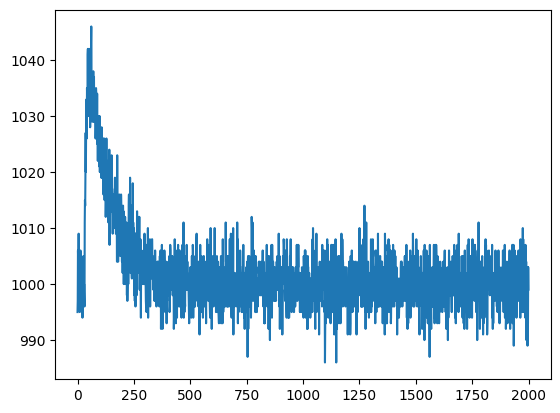